# FER Experiments
### Datasets
- FER2013
- CK+
- AffectNet
- RF-DB

In [1]:
import random
import tensorflow as tf
import numpy as np

SEED = 8

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)


In [2]:
import os, sys
module_path = os.path.abspath(os.path.join('..', '..')) 
sys.path.insert(0, module_path)
from src.data_loading import load_rafbd, load_ck, load_fer2013, load_affectnet, load_meld, filter_emotions, load_iemocap
from src.evaluation import plot_confusion_matrix, plot_training_history
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from keras.models import load_model
from PIL import Image
import cv2


def split_dataset_train_val_test(df, val_size=0.2, test_size=0.3, seed=SEED):
    train_val_df, test_df = train_test_split(df, test_size=test_size, random_state=seed, stratify=df['label'])
    train_df, val_df = train_test_split(train_val_df, test_size=val_size/(1 - test_size), random_state=seed, stratify=train_val_df['label'])
    return train_df, val_df, test_df

def preprocess_fer_row(pixels_str, target_size=(48, 48)):
    # Convert string of space-separated pixel values to 2D image
    pixels = np.fromstring(pixels_str, sep=' ', dtype=np.uint8)
    pixels = pixels.reshape(target_size)
    # Convert to float, normalize, and expand dims
    pixels = pixels.astype("float32") / 255.0
    pixels = np.expand_dims(pixels, axis=-1)
    return pixels

def preprocess_raf_row(filename):
    # read and convert image to grayscale
    image = Image.open(filename).convert('L')
    image = image.resize((48, 48))
    np_image = np.array(image).astype("float32") / 255.0
    np_image = np.expand_dims(np_image, axis=-1)
    return np_image


ck = filter_emotions(load_ck())
fer = filter_emotions(load_fer2013())
raf = filter_emotions(load_rafbd())
affect = filter_emotions(load_affectnet())

ck["pixels"] = ck["pixels"].apply(preprocess_fer_row)
fer["pixels"] = fer["pixels"].apply(preprocess_fer_row)
raf["pixels"] = raf["filename"].apply(preprocess_raf_row)
affect["pixels"] = affect["filename"].apply(preprocess_raf_row)

cols = ['pixels', 'label']
ck, fer, raf, affect = ck[cols], fer[cols], raf[cols], affect[cols]


ck_train, ck_val, ck_test = split_dataset_train_val_test(ck)
raf_train, raf_val, raf_test = split_dataset_train_val_test(raf)
affect_train, affect_val, affect_test = split_dataset_train_val_test(affect)
fer_train, fer_val, fer_test = split_dataset_train_val_test(fer)

/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Subfolders in the dataset: ['ckextended.csv']
Subfolders in the dataset: ['fer2013.csv']


100%|██████████| 3068/3068 [00:00<00:00, 4789.95it/s]


Dataset downloaded to: /Users/krazmic/.cache/kagglehub/datasets/mstjebashazida/affectnet/versions/1
Available folders: ['happy', 'Contempt', 'sad', 'fear', 'surprise', 'neutral', 'Anger', 'disgust']


100%|██████████| 8/8 [00:04<00:00,  1.60it/s]


In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from fer_cnn_utils import preprocess_frame, build_light_cnn
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization, Input
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam


def build_light_cnn(input_shape=(48, 48, 1), num_classes=7):
    """
    Lightweight CNN for emotion recognition from frames.
    """
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(256, (3,3), activation='relu', padding='same',),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),
        Dropout(0.7),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    
    

    optimizer = Adam(learning_rate=3e-4)
    model.compile(optimizer=optimizer, #'adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model



# FER2013 + RAF-DB

Epoch 1/100
609/609 [==============================] - ETA: 0s - loss: 1.9954 - accuracy: 0.2586
Epoch 1: val_accuracy improved from -inf to 0.33701, saving model to best_cnn_model.h5
609/609 [==============================] - 80s 127ms/step - loss: 1.9954 - accuracy: 0.2586 - val_loss: 1.7010 - val_accuracy: 0.3370 - lr: 3.0000e-04
Epoch 2/100


/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


609/609 [==============================] - ETA: 0s - loss: 1.6327 - accuracy: 0.3631
Epoch 2: val_accuracy improved from 0.33701 to 0.39900, saving model to best_cnn_model.h5
609/609 [==============================] - 74s 122ms/step - loss: 1.6327 - accuracy: 0.3631 - val_loss: 1.5429 - val_accuracy: 0.3990 - lr: 3.0000e-04
Epoch 3/100
609/609 [==============================] - ETA: 0s - loss: 1.5034 - accuracy: 0.4183
Epoch 3: val_accuracy improved from 0.39900 to 0.43493, saving model to best_cnn_model.h5
609/609 [==============================] - 74s 121ms/step - loss: 1.5034 - accuracy: 0.4183 - val_loss: 1.4721 - val_accuracy: 0.4349 - lr: 3.0000e-04
Epoch 4/100
609/609 [==============================] - ETA: 0s - loss: 1.4175 - accuracy: 0.4516
Epoch 4: val_accuracy improved from 0.43493 to 0.47266, saving model to best_cnn_model.h5
609/609 [==============================] - 77s 126ms/step - loss: 1.4175 - accuracy: 0.4516 - val_loss: 1.3569 - val_accuracy: 0.4727 - lr: 3.0000e-0

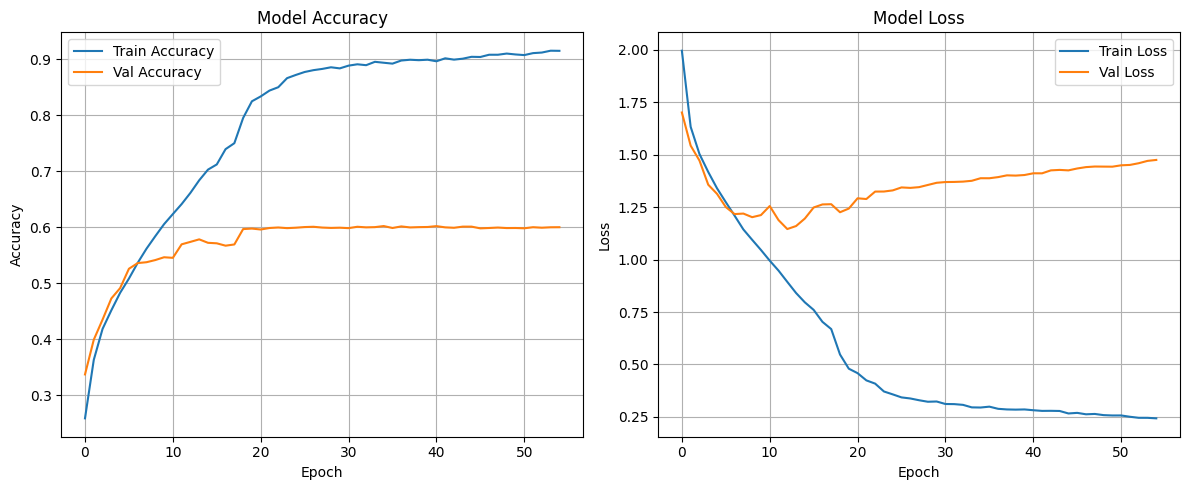

In [5]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([fer_train, raf_train])
df_val = pd.concat([fer_val, raf_val])
df_test = ck
#df_test = affect

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

29/29 [==============================] - 2s 32ms/step
              precision    recall  f1-score   support

       angry       0.22      0.36      0.27        45
     disgust       1.00      0.08      0.16        59
        fear       0.12      0.08      0.10        25
       happy       0.82      1.00      0.90        69
     neutral       0.91      0.91      0.91       593
         sad       0.12      0.21      0.15        28
    surprise       0.96      0.86      0.90        83

    accuracy                           0.79       902
   macro avg       0.59      0.50      0.48       902
weighted avg       0.83      0.79      0.78       902



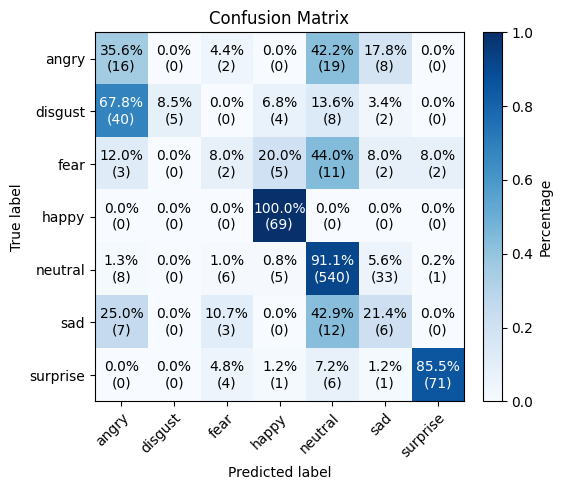

413/413 [==============================] - 14s 33ms/step
              precision    recall  f1-score   support

       angry       0.32      0.43      0.36      1718
     disgust       0.54      0.01      0.01      1248
        fear       0.31      0.21      0.25      1664
       happy       0.59      0.67      0.63      2704
     neutral       0.28      0.46      0.35      2368
         sad       0.22      0.30      0.25      1584
    surprise       0.45      0.13      0.20      1920

    accuracy                           0.36     13206
   macro avg       0.39      0.32      0.29     13206
weighted avg       0.39      0.36      0.33     13206



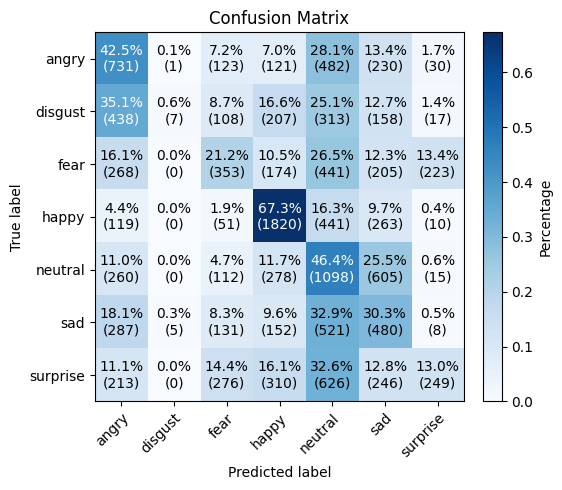

In [6]:
## CK
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

## AffectNet
df_test = affect
X_test  = np.stack(df_test["pixels"].values)
y_test = label_encoder.transform(df_test['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)


### FER2013, RAF-DB, AffectNet

2026-01-20 22:08:00.467738: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-01-20 22:08:00.467940: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-01-20 22:08:00.467947: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-01-20 22:08:00.468495: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-20 22:08:00.468859: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/100


2026-01-20 22:08:02.035562: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-01-20 22:08:02.124268: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


815/815 [==============================] - ETA: 0s - loss: 3.5619 - accuracy: 0.2175
Epoch 1: val_accuracy improved from -inf to 0.28790, saving model to best_cnn_model.h5
815/815 [==============================] - 26s 30ms/step - loss: 3.5619 - accuracy: 0.2175 - val_loss: 2.2250 - val_accuracy: 0.2879 - lr: 3.0000e-04
Epoch 2/100


/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


815/815 [==============================] - ETA: 0s - loss: 2.9854 - accuracy: 0.2751
Epoch 2: val_accuracy improved from 0.28790 to 0.34943, saving model to best_cnn_model.h5
815/815 [==============================] - 25s 30ms/step - loss: 2.9854 - accuracy: 0.2751 - val_loss: 1.9358 - val_accuracy: 0.3494 - lr: 3.0000e-04
Epoch 3/100
815/815 [==============================] - ETA: 0s - loss: 2.4814 - accuracy: 0.3503
Epoch 3: val_accuracy improved from 0.34943 to 0.41518, saving model to best_cnn_model.h5
815/815 [==============================] - 24s 30ms/step - loss: 2.4814 - accuracy: 0.3503 - val_loss: 1.7378 - val_accuracy: 0.4152 - lr: 3.0000e-04
Epoch 4/100
815/815 [==============================] - ETA: 0s - loss: 2.0376 - accuracy: 0.4075
Epoch 4: val_accuracy improved from 0.41518 to 0.45611, saving model to best_cnn_model.h5
815/815 [==============================] - 25s 30ms/step - loss: 2.0376 - accuracy: 0.4075 - val_loss: 1.5286 - val_accuracy: 0.4561 - lr: 3.0000e-04
E

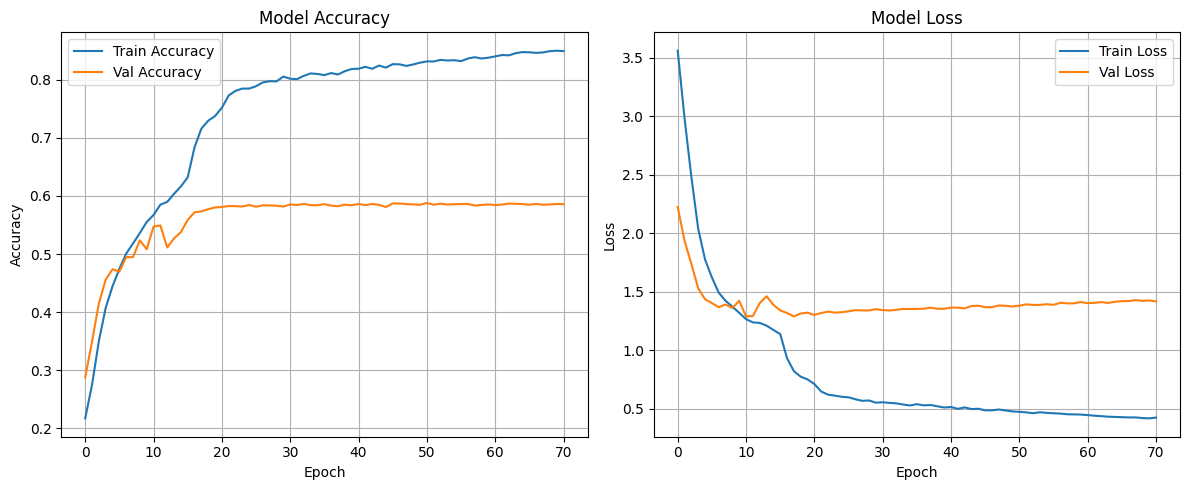

In [4]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([fer_train, raf_train, affect_train])
df_val = pd.concat([fer_val, raf_val, affect_val])
df_test = ck
#df_test = affect

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

29/29 [==============================] - 0s 8ms/step
              precision    recall  f1-score   support

       angry       0.17      0.24      0.20        45
     disgust       0.91      0.17      0.29        59
        fear       0.33      0.28      0.30        25
       happy       0.87      1.00      0.93        69
     neutral       0.91      0.86      0.88       593
         sad       0.15      0.43      0.22        28
    surprise       0.89      0.95      0.92        83

    accuracy                           0.77       902
   macro avg       0.61      0.56      0.54       902
weighted avg       0.83      0.77      0.78       902



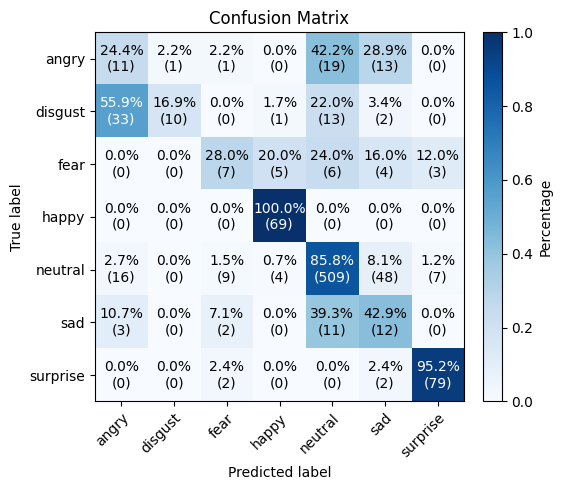

In [5]:
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

### FER2013, AffectNet

Epoch 1/100


2026-01-20 22:34:56.946561: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


766/767 [============================>.] - ETA: 0s - loss: 3.5306 - accuracy: 0.2164
Epoch 1: val_accuracy improved from -inf to 0.28248, saving model to best_cnn_model.h5
767/767 [==============================] - 23s 28ms/step - loss: 3.5296 - accuracy: 0.2165 - val_loss: 1.9222 - val_accuracy: 0.2825 - lr: 3.0000e-04
Epoch 2/100
  4/767 [..............................] - ETA: 17s - loss: 2.7958 - accuracy: 0.2891

/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


767/767 [==============================] - ETA: 0s - loss: 2.9227 - accuracy: 0.2735
Epoch 2: val_accuracy improved from 0.28248 to 0.36456, saving model to best_cnn_model.h5
767/767 [==============================] - 20s 27ms/step - loss: 2.9227 - accuracy: 0.2735 - val_loss: 1.9202 - val_accuracy: 0.3646 - lr: 3.0000e-04
Epoch 3/100
767/767 [==============================] - ETA: 0s - loss: 2.4540 - accuracy: 0.3463
Epoch 3: val_accuracy did not improve from 0.36456
767/767 [==============================] - 20s 26ms/step - loss: 2.4540 - accuracy: 0.3463 - val_loss: 2.2088 - val_accuracy: 0.3395 - lr: 3.0000e-04
Epoch 4/100
765/767 [============================>.] - ETA: 0s - loss: 2.0489 - accuracy: 0.3915
Epoch 4: val_accuracy improved from 0.36456 to 0.44328, saving model to best_cnn_model.h5
767/767 [==============================] - 20s 27ms/step - loss: 2.0484 - accuracy: 0.3913 - val_loss: 1.5037 - val_accuracy: 0.4433 - lr: 3.0000e-04
Epoch 5/100
767/767 [===================

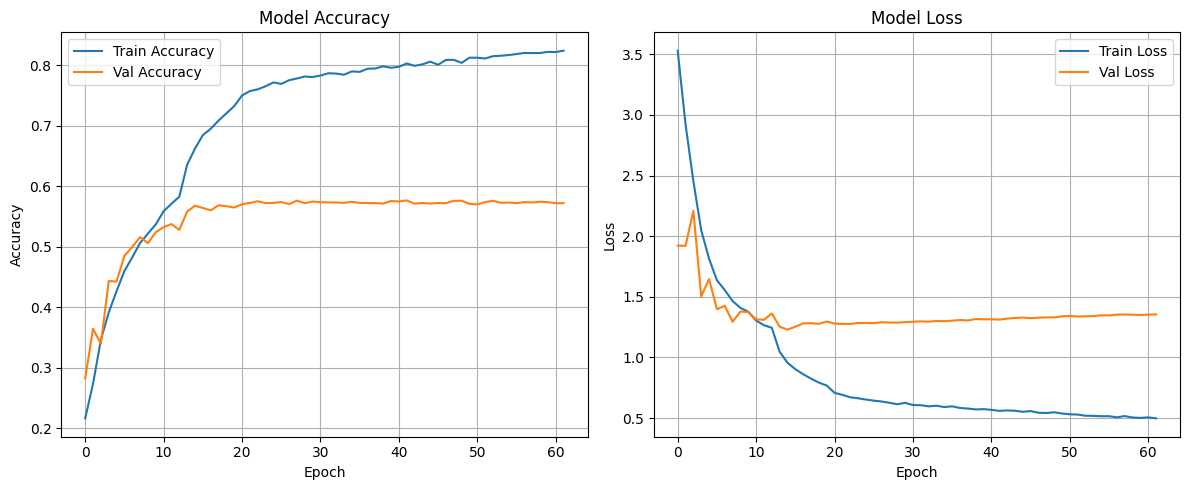

In [6]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([fer_train, affect_train])
df_val = pd.concat([fer_val, affect_val])
df_test = ck
#df_test = raf

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

29/29 [==============================] - 0s 7ms/step
              precision    recall  f1-score   support

       angry       0.17      0.29      0.21        45
     disgust       1.00      0.14      0.24        59
        fear       0.24      0.32      0.28        25
       happy       0.86      1.00      0.93        69
     neutral       0.92      0.86      0.89       593
         sad       0.23      0.61      0.34        28
    surprise       0.86      0.78      0.82        83

    accuracy                           0.76       902
   macro avg       0.61      0.57      0.53       902
weighted avg       0.84      0.76      0.77       902



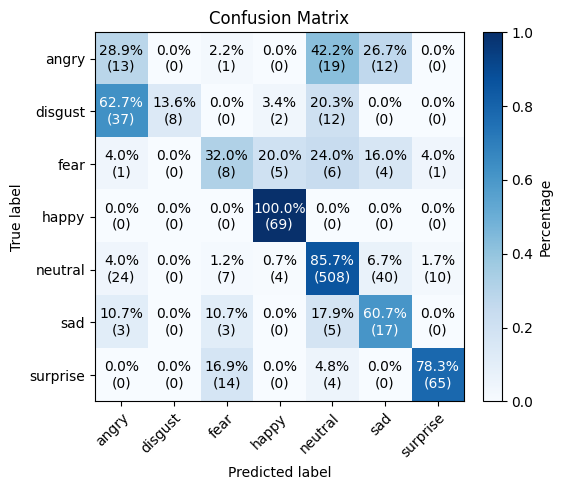

96/96 [==============================] - 1s 7ms/step
              precision    recall  f1-score   support

       angry       0.25      0.58      0.35       162
     disgust       0.67      0.01      0.02       160
        fear       0.06      0.19      0.09        74
       happy       0.80      0.76      0.78      1185
     neutral       0.52      0.54      0.53       680
         sad       0.38      0.46      0.42       478
    surprise       0.91      0.13      0.22       329

    accuracy                           0.53      3068
   macro avg       0.51      0.38      0.34      3068
weighted avg       0.63      0.53      0.53      3068



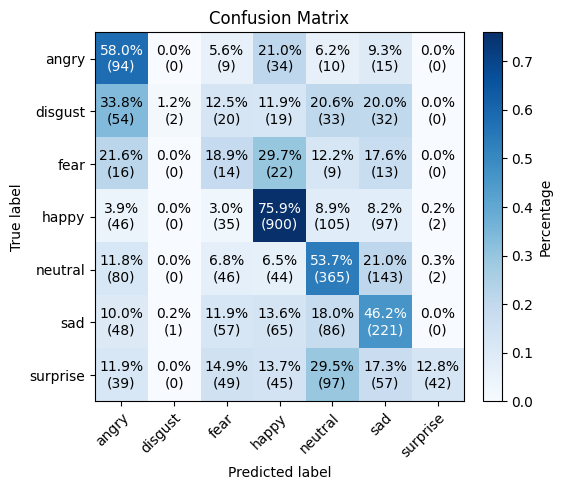

In [7]:
## CK
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

## RAF
df_test = raf
X_test  = np.stack(df_test["pixels"].values)
y_test = label_encoder.transform(df_test['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)


### RAF-DB, AffectNet

Epoch 1/100


2026-01-20 22:55:44.975430: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


255/255 [==============================] - ETA: 0s - loss: 4.0106 - accuracy: 0.2446
Epoch 1: val_accuracy improved from -inf to 0.23894, saving model to best_cnn_model.h5
255/255 [==============================] - 12s 39ms/step - loss: 4.0106 - accuracy: 0.2446 - val_loss: 2.4458 - val_accuracy: 0.2389 - lr: 3.0000e-04
Epoch 2/100
  1/255 [..............................] - ETA: 9s - loss: 3.1538 - accuracy: 0.2188

/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


252/255 [============================>.] - ETA: 0s - loss: 2.7927 - accuracy: 0.3182
Epoch 2: val_accuracy improved from 0.23894 to 0.32463, saving model to best_cnn_model.h5
255/255 [==============================] - 7s 29ms/step - loss: 2.7893 - accuracy: 0.3186 - val_loss: 1.9899 - val_accuracy: 0.3246 - lr: 3.0000e-04
Epoch 3/100
254/255 [============================>.] - ETA: 0s - loss: 2.5614 - accuracy: 0.3455
Epoch 3: val_accuracy improved from 0.32463 to 0.39343, saving model to best_cnn_model.h5
255/255 [==============================] - 7s 29ms/step - loss: 2.5619 - accuracy: 0.3453 - val_loss: 1.7572 - val_accuracy: 0.3934 - lr: 3.0000e-04
Epoch 4/100
253/255 [============================>.] - ETA: 0s - loss: 2.4613 - accuracy: 0.3730
Epoch 4: val_accuracy improved from 0.39343 to 0.46038, saving model to best_cnn_model.h5
255/255 [==============================] - 7s 29ms/step - loss: 2.4619 - accuracy: 0.3730 - val_loss: 1.7063 - val_accuracy: 0.4604 - lr: 3.0000e-04
Epoc

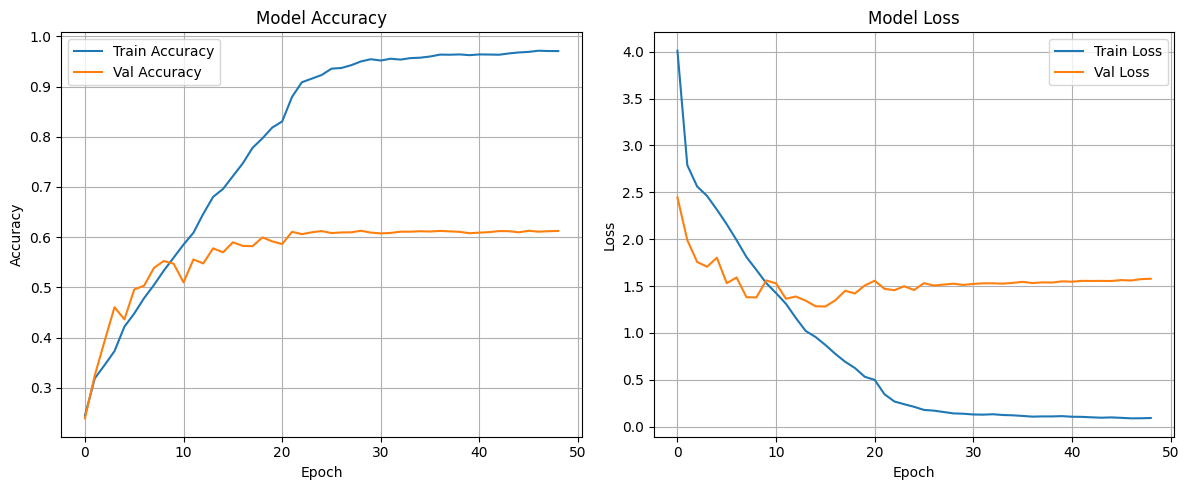

In [8]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([raf_train, affect_train])
df_val = pd.concat([raf_val, affect_val])
df_test = ck
#df_test = fer

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

29/29 [==============================] - 0s 6ms/step
              precision    recall  f1-score   support

       angry       0.14      0.60      0.22        45
     disgust       0.27      0.47      0.34        59
        fear       0.04      0.68      0.08        25
       happy       1.00      0.07      0.14        69
     neutral       0.00      0.00      0.00       593
         sad       0.06      0.25      0.09        28
    surprise       0.49      0.45      0.47        83

    accuracy                           0.13       902
   macro avg       0.28      0.36      0.19       902
weighted avg       0.15      0.13      0.09       902



/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

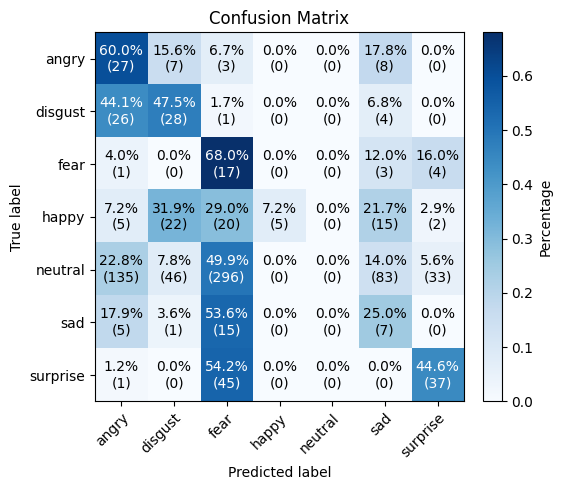

1122/1122 [==============================] - 7s 7ms/step
              precision    recall  f1-score   support

       angry       0.29      0.24      0.26      4953
     disgust       0.04      0.28      0.07       547
        fear       0.19      0.28      0.23      5121
       happy       0.57      0.21      0.31      8989
     neutral       0.25      0.12      0.16      6198
         sad       0.25      0.32      0.28      6077
    surprise       0.29      0.47      0.36      4002

    accuracy                           0.26     35887
   macro avg       0.27      0.28      0.24     35887
weighted avg       0.33      0.26      0.26     35887



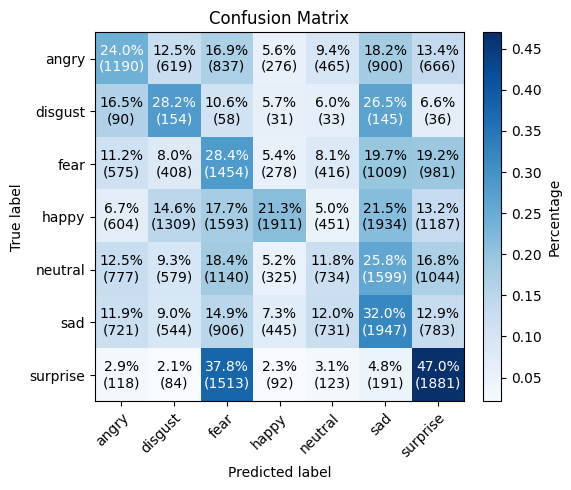

In [9]:
## CK
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

## FER
df_test = fer
X_test  = np.stack(df_test["pixels"].values)
y_test = label_encoder.transform(df_test['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)


### CK, RAF-DB

Epoch 1/100


2026-01-20 23:01:39.126838: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


62/62 [==============================] - ETA: 0s - loss: 4.1405 - accuracy: 0.3424
Epoch 1: val_accuracy improved from -inf to 0.31572, saving model to best_cnn_model.h5
62/62 [==============================] - 5s 59ms/step - loss: 4.1405 - accuracy: 0.3424 - val_loss: 1.9315 - val_accuracy: 0.3157 - lr: 3.0000e-04
Epoch 2/100
 5/62 [=>............................] - ETA: 0s - loss: 2.7886 - accuracy: 0.4125

/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


62/62 [==============================] - ETA: 0s - loss: 2.7024 - accuracy: 0.4372
Epoch 2: val_accuracy did not improve from 0.31572
62/62 [==============================] - 2s 30ms/step - loss: 2.7024 - accuracy: 0.4372 - val_loss: 2.2119 - val_accuracy: 0.0981 - lr: 3.0000e-04
Epoch 3/100
62/62 [==============================] - ETA: 0s - loss: 2.2771 - accuracy: 0.4856
Epoch 3: val_accuracy did not improve from 0.31572
62/62 [==============================] - 2s 30ms/step - loss: 2.2771 - accuracy: 0.4856 - val_loss: 2.1716 - val_accuracy: 0.3157 - lr: 3.0000e-04
Epoch 4/100
60/62 [============================>.] - ETA: 0s - loss: 2.1117 - accuracy: 0.4948
Epoch 4: val_accuracy improved from 0.31572 to 0.31824, saving model to best_cnn_model.h5
62/62 [==============================] - 2s 29ms/step - loss: 2.1107 - accuracy: 0.4947 - val_loss: 2.1816 - val_accuracy: 0.3182 - lr: 3.0000e-04
Epoch 5/100
61/62 [============================>.] - ETA: 0s - loss: 1.9489 - accuracy: 0.5149

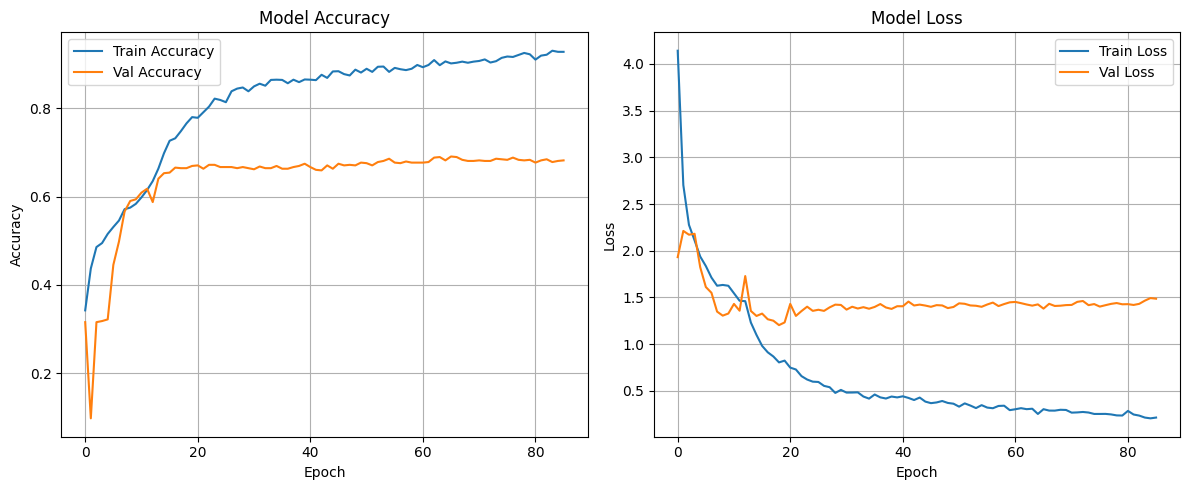

In [10]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([raf_train, ck_train])
df_val = pd.concat([raf_val, ck_val])
df_test = affect
#df_test = fer

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

413/413 [==============================] - 2s 5ms/step
              precision    recall  f1-score   support

       angry       0.29      0.10      0.15      1718
     disgust       0.17      0.10      0.12      1248
        fear       0.15      0.03      0.05      1664
       happy       0.33      0.25      0.28      2704
     neutral       0.19      0.31      0.24      2368
         sad       0.13      0.32      0.18      1584
    surprise       0.23      0.20      0.22      1920

    accuracy                           0.20     13206
   macro avg       0.21      0.19      0.18     13206
weighted avg       0.22      0.20      0.19     13206



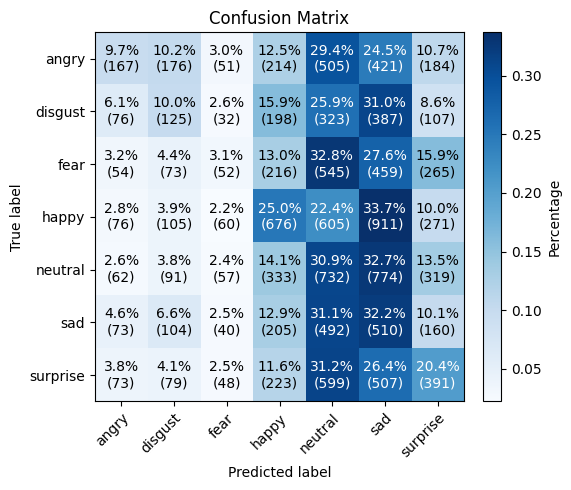

1122/1122 [==============================] - 7s 6ms/step
              precision    recall  f1-score   support

       angry       0.28      0.10      0.14      4953
     disgust       0.03      0.11      0.05       547
        fear       0.19      0.02      0.04      5121
       happy       0.50      0.51      0.51      8989
     neutral       0.31      0.44      0.37      6198
         sad       0.25      0.34      0.29      6077
    surprise       0.39      0.50      0.44      4002

    accuracy                           0.34     35887
   macro avg       0.28      0.29      0.26     35887
weighted avg       0.33      0.34      0.31     35887



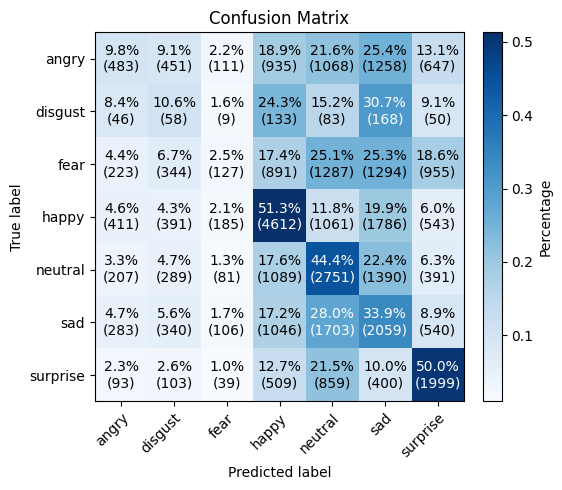

In [11]:
## AN
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

## FER
df_test = fer
X_test  = np.stack(df_test["pixels"].values)
y_test = label_encoder.transform(df_test['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)


### CK, RAF-DB, AffectNet

Epoch 1/100


2026-01-20 23:04:22.957606: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


269/269 [==============================] - ETA: 0s - loss: 4.0029 - accuracy: 0.2309
Epoch 1: val_accuracy improved from -inf to 0.19930, saving model to best_cnn_model.h5
269/269 [==============================] - 11s 37ms/step - loss: 4.0029 - accuracy: 0.2309 - val_loss: 2.1273 - val_accuracy: 0.1993 - lr: 3.0000e-04
Epoch 2/100
  1/269 [..............................] - ETA: 20s - loss: 2.8132 - accuracy: 0.2500

/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


266/269 [============================>.] - ETA: 0s - loss: 2.9416 - accuracy: 0.2776
Epoch 2: val_accuracy improved from 0.19930 to 0.31772, saving model to best_cnn_model.h5
269/269 [==============================] - 8s 29ms/step - loss: 2.9435 - accuracy: 0.2771 - val_loss: 1.9158 - val_accuracy: 0.3177 - lr: 3.0000e-04
Epoch 3/100
269/269 [==============================] - ETA: 0s - loss: 2.6351 - accuracy: 0.3259
Epoch 3: val_accuracy improved from 0.31772 to 0.39395, saving model to best_cnn_model.h5
269/269 [==============================] - 8s 29ms/step - loss: 2.6351 - accuracy: 0.3259 - val_loss: 1.7677 - val_accuracy: 0.3939 - lr: 3.0000e-04
Epoch 4/100
268/269 [============================>.] - ETA: 0s - loss: 2.5268 - accuracy: 0.3559
Epoch 4: val_accuracy improved from 0.39395 to 0.42217, saving model to best_cnn_model.h5
269/269 [==============================] - 8s 29ms/step - loss: 2.5262 - accuracy: 0.3557 - val_loss: 1.6615 - val_accuracy: 0.4222 - lr: 3.0000e-04
Epoc

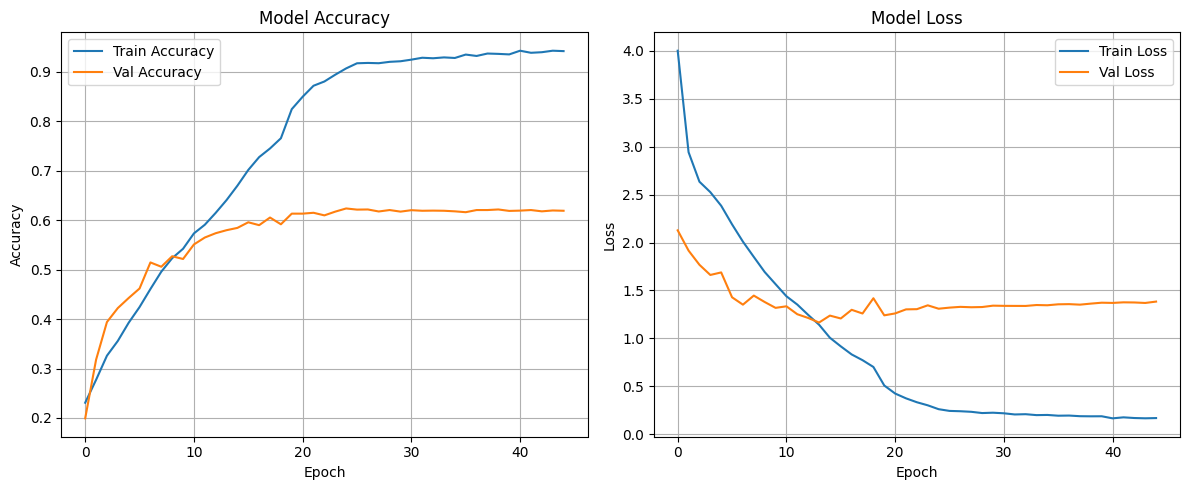

In [12]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([ck_train, raf_train, affect_train])
df_val = pd.concat([ck_val, raf_val, affect_val])
df_test = fer
#df_test = affect

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

1122/1122 [==============================] - 8s 7ms/step
              precision    recall  f1-score   support

       angry       0.26      0.27      0.27      4953
     disgust       0.03      0.28      0.06       547
        fear       0.23      0.21      0.22      5121
       happy       0.70      0.27      0.39      8989
     neutral       0.30      0.16      0.21      6198
         sad       0.29      0.34      0.31      6077
    surprise       0.28      0.55      0.37      4002

    accuracy                           0.29     35887
   macro avg       0.30      0.30      0.26     35887
weighted avg       0.38      0.29      0.30     35887



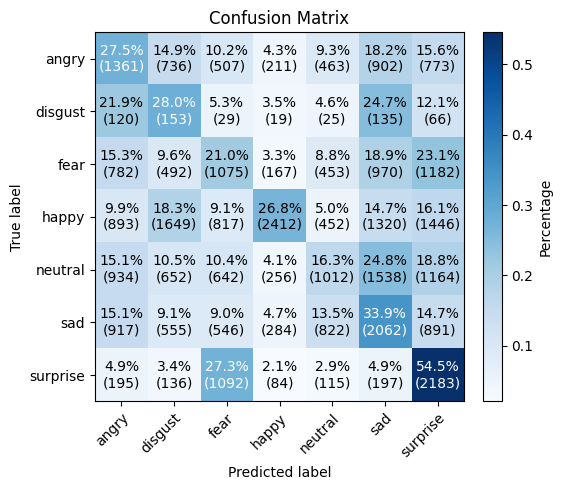

In [13]:
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

### CK, AffectNet

Epoch 1/100


2026-01-20 23:10:19.945688: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


221/221 [==============================] - ETA: 0s - loss: 4.2509 - accuracy: 0.2395
Epoch 1: val_accuracy improved from -inf to 0.21396, saving model to best_cnn_model.h5
221/221 [==============================] - 10s 41ms/step - loss: 4.2509 - accuracy: 0.2395 - val_loss: 2.0567 - val_accuracy: 0.2140 - lr: 3.0000e-04
Epoch 2/100
  1/221 [..............................] - ETA: 21s - loss: 3.3034 - accuracy: 0.3438

/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


221/221 [==============================] - ETA: 0s - loss: 3.0389 - accuracy: 0.3098
Epoch 2: val_accuracy improved from 0.21396 to 0.31456, saving model to best_cnn_model.h5
221/221 [==============================] - 6s 29ms/step - loss: 3.0389 - accuracy: 0.3098 - val_loss: 1.8313 - val_accuracy: 0.3146 - lr: 3.0000e-04
Epoch 3/100
221/221 [==============================] - ETA: 0s - loss: 2.7155 - accuracy: 0.3349
Epoch 3: val_accuracy improved from 0.31456 to 0.39001, saving model to best_cnn_model.h5
221/221 [==============================] - 6s 29ms/step - loss: 2.7155 - accuracy: 0.3349 - val_loss: 1.8935 - val_accuracy: 0.3900 - lr: 3.0000e-04
Epoch 4/100
221/221 [==============================] - ETA: 0s - loss: 2.5814 - accuracy: 0.3626
Epoch 4: val_accuracy improved from 0.39001 to 0.40028, saving model to best_cnn_model.h5
221/221 [==============================] - 6s 29ms/step - loss: 2.5814 - accuracy: 0.3626 - val_loss: 1.9760 - val_accuracy: 0.4003 - lr: 3.0000e-04
Epoc

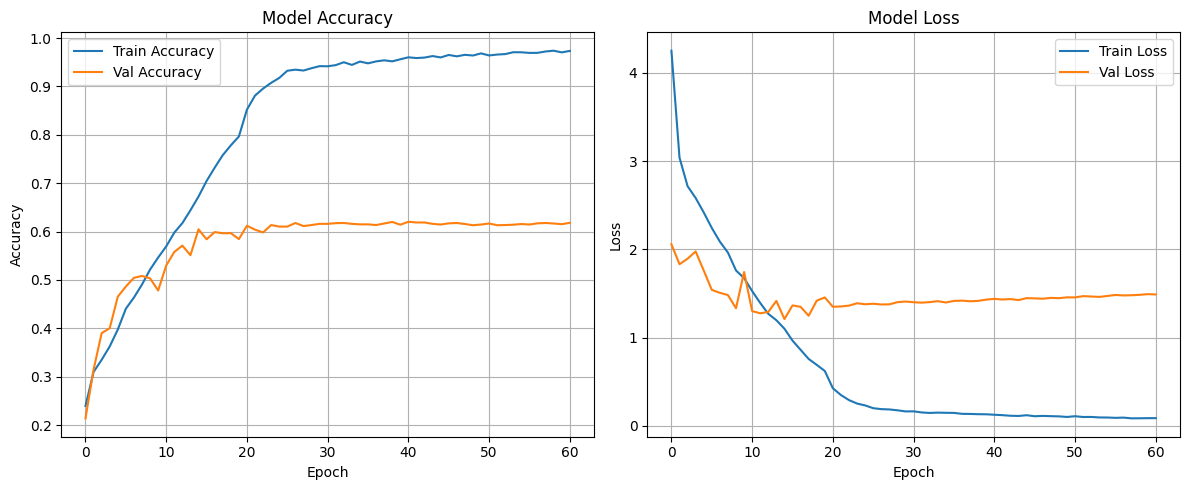

In [14]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([ck_train, affect_train])
df_val = pd.concat([ck_val, affect_val])
df_test = fer
#df_test = raf

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

1122/1122 [==============================] - 8s 7ms/step
              precision    recall  f1-score   support

       angry       0.26      0.26      0.26      4953
     disgust       0.04      0.33      0.07       547
        fear       0.18      0.32      0.23      5121
       happy       0.50      0.10      0.16      8989
     neutral       0.33      0.09      0.14      6198
         sad       0.26      0.25      0.26      6077
    surprise       0.26      0.50      0.34      4002

    accuracy                           0.23     35887
   macro avg       0.26      0.26      0.21     35887
weighted avg       0.32      0.23      0.22     35887



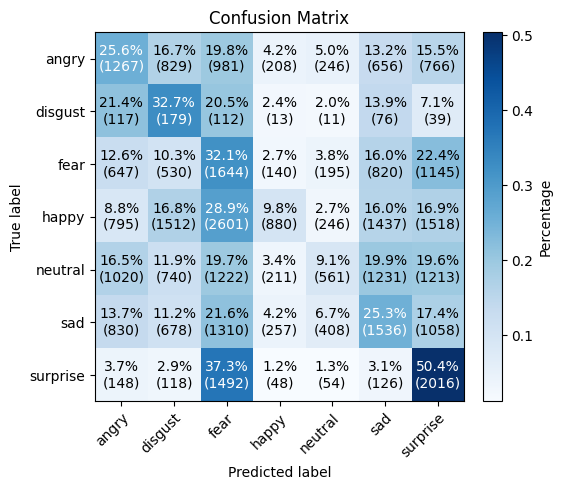

96/96 [==============================] - 1s 7ms/step
              precision    recall  f1-score   support

       angry       0.13      0.31      0.19       162
     disgust       0.08      0.23      0.12       160
        fear       0.03      0.42      0.06        74
       happy       0.52      0.15      0.24      1185
     neutral       0.55      0.09      0.15       680
         sad       0.26      0.32      0.28       478
    surprise       0.28      0.18      0.22       329

    accuracy                           0.19      3068
   macro avg       0.26      0.24      0.18      3068
weighted avg       0.40      0.19      0.21      3068



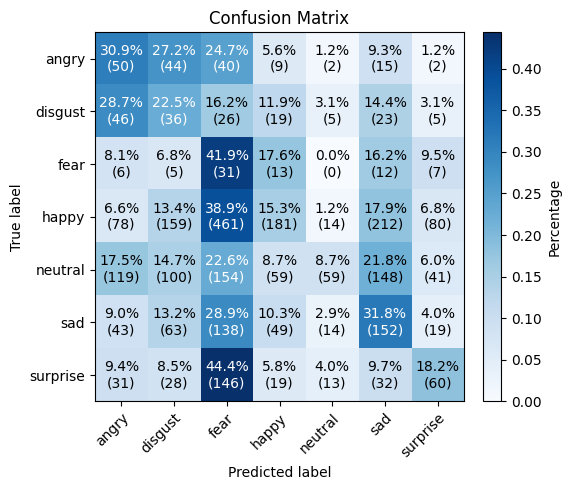

In [15]:
## FER
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

## RAF
df_test = raf
X_test  = np.stack(df_test["pixels"].values)
y_test = label_encoder.transform(df_test['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)


### FER2012, CK, AffectNet

Epoch 1/100


2026-01-20 23:16:47.600078: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


782/782 [==============================] - ETA: 0s - loss: 3.5200 - accuracy: 0.2188
Epoch 1: val_accuracy improved from -inf to 0.29517, saving model to best_cnn_model.h5
782/782 [==============================] - 25s 30ms/step - loss: 3.5200 - accuracy: 0.2188 - val_loss: 2.1340 - val_accuracy: 0.2952 - lr: 3.0000e-04
Epoch 2/100
  1/782 [..............................] - ETA: 1:04 - loss: 2.7343 - accuracy: 0.2812

/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


781/782 [============================>.] - ETA: 0s - loss: 3.0354 - accuracy: 0.2496
Epoch 2: val_accuracy improved from 0.29517 to 0.31067, saving model to best_cnn_model.h5
782/782 [==============================] - 23s 29ms/step - loss: 3.0358 - accuracy: 0.2496 - val_loss: 1.9651 - val_accuracy: 0.3107 - lr: 3.0000e-04
Epoch 3/100
780/782 [============================>.] - ETA: 0s - loss: 2.4765 - accuracy: 0.3444
Epoch 3: val_accuracy improved from 0.31067 to 0.42226, saving model to best_cnn_model.h5
782/782 [==============================] - 22s 29ms/step - loss: 2.4760 - accuracy: 0.3444 - val_loss: 1.5789 - val_accuracy: 0.4223 - lr: 3.0000e-04
Epoch 4/100
780/782 [============================>.] - ETA: 0s - loss: 2.0061 - accuracy: 0.4070
Epoch 4: val_accuracy did not improve from 0.42226
782/782 [==============================] - 23s 29ms/step - loss: 2.0060 - accuracy: 0.4070 - val_loss: 1.8022 - val_accuracy: 0.3896 - lr: 3.0000e-04
Epoch 5/100
782/782 [===================

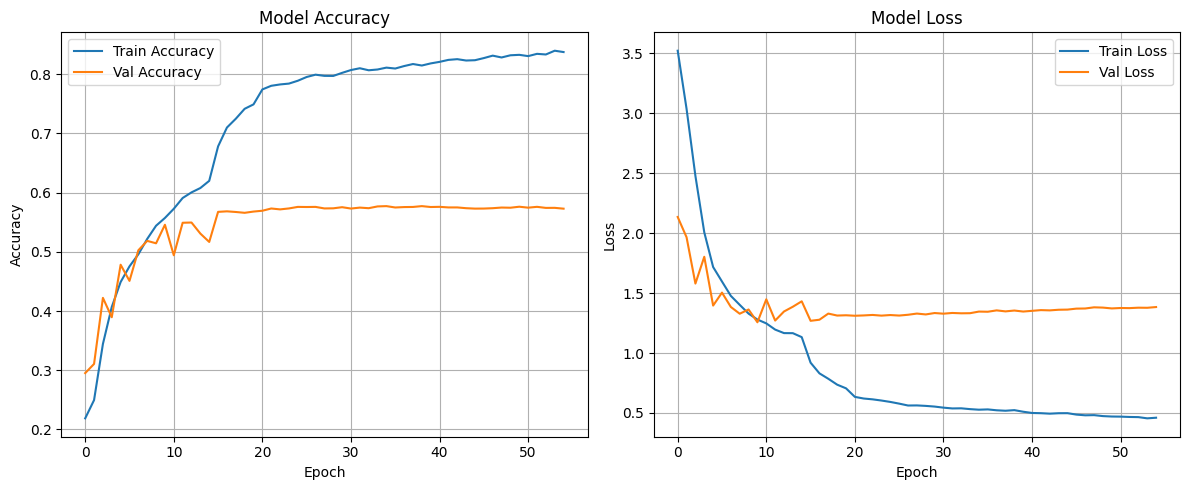

In [16]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([fer_train, ck_train, affect_train])
df_val = pd.concat([fer_val, ck_val, affect_val])
#df_test = fer
df_test = raf

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

96/96 [==============================] - 1s 7ms/step
              precision    recall  f1-score   support

       angry       0.25      0.59      0.35       162
     disgust       0.10      0.01      0.01       160
        fear       0.05      0.12      0.07        74
       happy       0.76      0.77      0.77      1185
     neutral       0.55      0.44      0.49       680
         sad       0.32      0.47      0.38       478
    surprise       0.85      0.12      0.22       329

    accuracy                           0.52      3068
   macro avg       0.41      0.36      0.33      3068
weighted avg       0.58      0.52      0.51      3068



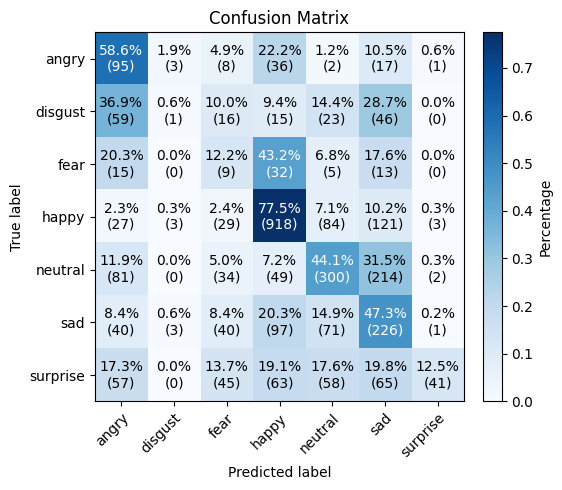

In [17]:
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

### CK, FER2013

Epoch 1/100


2026-01-20 23:36:32.246819: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


575/575 [==============================] - ETA: 0s - loss: 3.3755 - accuracy: 0.2501
Epoch 1: val_accuracy improved from -inf to 0.26036, saving model to best_cnn_model.h5
575/575 [==============================] - 20s 33ms/step - loss: 3.3755 - accuracy: 0.2501 - val_loss: 1.9551 - val_accuracy: 0.2604 - lr: 3.0000e-04
Epoch 2/100
  1/575 [..............................] - ETA: 54s - loss: 2.4226 - accuracy: 0.3438

/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


575/575 [==============================] - ETA: 0s - loss: 2.7132 - accuracy: 0.2956
Epoch 2: val_accuracy improved from 0.26036 to 0.33265, saving model to best_cnn_model.h5
575/575 [==============================] - 17s 30ms/step - loss: 2.7132 - accuracy: 0.2956 - val_loss: 1.9596 - val_accuracy: 0.3327 - lr: 3.0000e-04
Epoch 3/100
575/575 [==============================] - ETA: 0s - loss: 2.5849 - accuracy: 0.3281
Epoch 3: val_accuracy improved from 0.33265 to 0.38714, saving model to best_cnn_model.h5
575/575 [==============================] - 16s 29ms/step - loss: 2.5849 - accuracy: 0.3281 - val_loss: 1.7825 - val_accuracy: 0.3871 - lr: 3.0000e-04
Epoch 4/100
575/575 [==============================] - ETA: 0s - loss: 2.2980 - accuracy: 0.3652
Epoch 4: val_accuracy improved from 0.38714 to 0.41650, saving model to best_cnn_model.h5
575/575 [==============================] - 14s 24ms/step - loss: 2.2980 - accuracy: 0.3652 - val_loss: 1.6787 - val_accuracy: 0.4165 - lr: 3.0000e-04
E

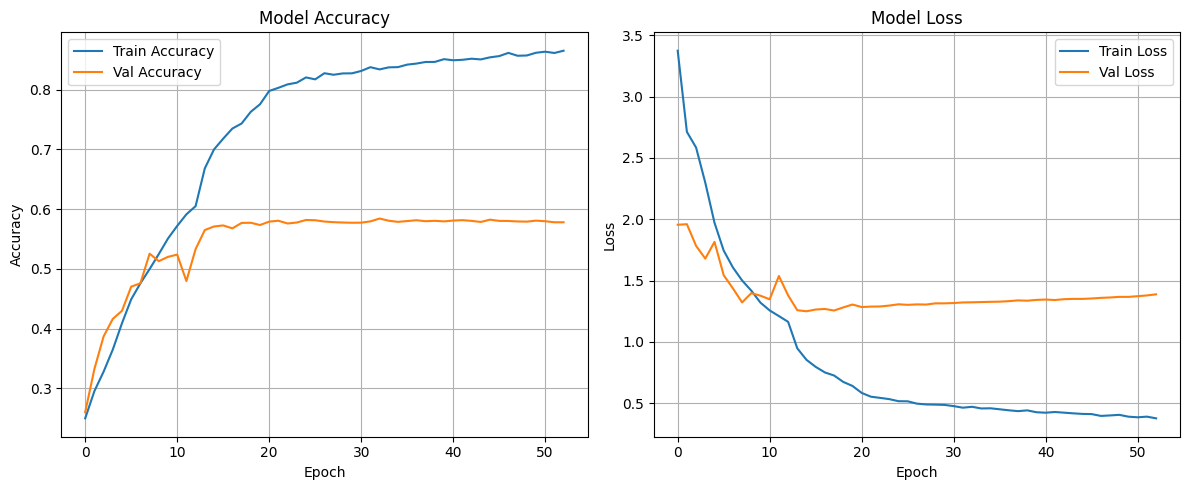

In [18]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([fer_train, ck_train])
df_val = pd.concat([fer_val, ck_val])

#df_test = raf
df_test = affect

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

413/413 [==============================] - 3s 7ms/step
              precision    recall  f1-score   support

       angry       0.31      0.41      0.35      1718
     disgust       0.75      0.00      0.01      1248
        fear       0.32      0.17      0.22      1664
       happy       0.49      0.72      0.58      2704
     neutral       0.24      0.32      0.28      2368
         sad       0.19      0.29      0.23      1584
    surprise       0.43      0.12      0.19      1920

    accuracy                           0.33     13206
   macro avg       0.39      0.29      0.27     13206
weighted avg       0.38      0.33      0.30     13206



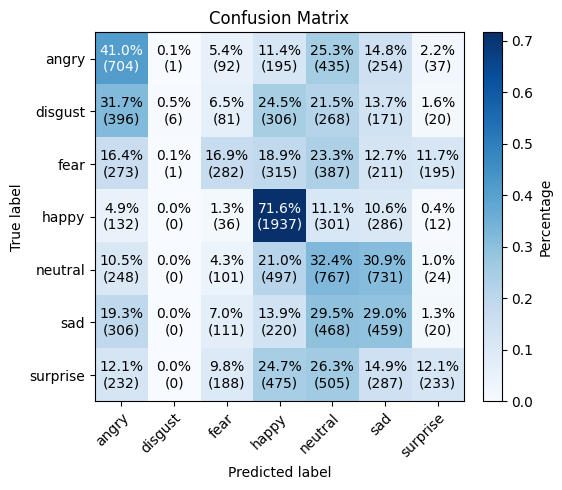

96/96 [==============================] - 1s 8ms/step
              precision    recall  f1-score   support

       angry       0.27      0.47      0.34       162
     disgust       0.25      0.01      0.01       160
        fear       0.05      0.16      0.08        74
       happy       0.73      0.84      0.78      1185
     neutral       0.54      0.48      0.51       680
         sad       0.38      0.41      0.39       478
    surprise       0.77      0.14      0.24       329

    accuracy                           0.54      3068
   macro avg       0.43      0.36      0.34      3068
weighted avg       0.57      0.54      0.52      3068



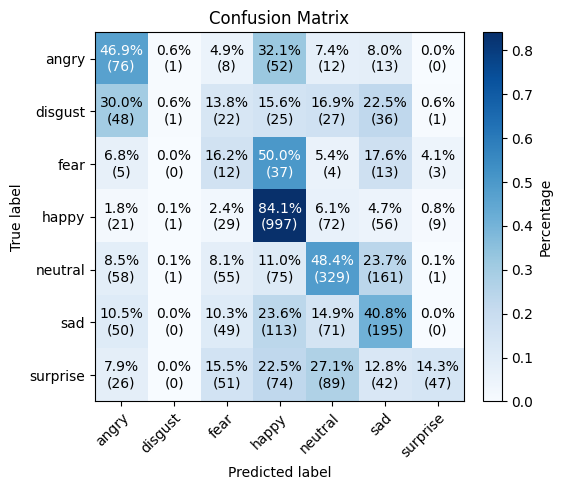

In [19]:
## AN
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

## RAF
df_test = raf
X_test  = np.stack(df_test["pixels"].values)
y_test = label_encoder.transform(df_test['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)


### FER2013, RAF-DB, CK+

In [ ]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([fer_train, ck_train, raf_train])
df_val = pd.concat([fer_val, ck_val, raf_val])

#df_test = raf
df_test = affect

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

Epoch 1/100


2026-01-20 23:51:03.040398: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


623/623 [==============================] - ETA: 0s - loss: 3.4432 - accuracy: 0.2545
Epoch 1: val_accuracy improved from -inf to 0.34767, saving model to best_cnn_model.h5
623/623 [==============================] - 22s 33ms/step - loss: 3.4432 - accuracy: 0.2545 - val_loss: 1.8773 - val_accuracy: 0.3477 - lr: 3.0000e-04
Epoch 2/100
  1/623 [..............................] - ETA: 1:00 - loss: 3.2313 - accuracy: 0.2188

/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


623/623 [==============================] - ETA: 0s - loss: 2.7268 - accuracy: 0.3023
Epoch 2: val_accuracy improved from 0.34767 to 0.39333, saving model to best_cnn_model.h5
623/623 [==============================] - 18s 30ms/step - loss: 2.7268 - accuracy: 0.3023 - val_loss: 1.8491 - val_accuracy: 0.3933 - lr: 3.0000e-04
Epoch 3/100
623/623 [==============================] - ETA: 0s - loss: 2.5699 - accuracy: 0.3448
Epoch 3: val_accuracy improved from 0.39333 to 0.40600, saving model to best_cnn_model.h5
623/623 [==============================] - 18s 29ms/step - loss: 2.5699 - accuracy: 0.3448 - val_loss: 1.6803 - val_accuracy: 0.4060 - lr: 3.0000e-04
Epoch 4/100
623/623 [==============================] - ETA: 0s - loss: 2.2656 - accuracy: 0.3939
Epoch 4: val_accuracy improved from 0.40600 to 0.45780, saving model to best_cnn_model.h5
623/623 [==============================] - 18s 29ms/step - loss: 2.2656 - accuracy: 0.3939 - val_loss: 1.6280 - val_accuracy: 0.4578 - lr: 3.0000e-04
E

In [ ]:
## AN
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)